In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose # Decomposition
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error

%matplotlib inline

In [ ]:
# SARIMAX -- if you do not use Seasonal order then you are building ARIMA - No Seasonality ( transformation, diff, log, sqrt)
# if you are using Sesonal order (P, D, Q, Seasonal_order) , SARIMA - Seasonality

In [3]:
# TimeSeries with Exogeneous variables (X Variables)


data = pd.read_csv(r'C:\Users\sneha\anaconda assignment\excel/Sales-and-Marketing.csv')

In [4]:
data.head()

,Time Period,Sales,Marketing Expense
0,Jan-11,397,486.64
1,Feb-11,400,501.80
2,Mar-11,498,437.09
3,Apr-11,536,565.16
4,May-11,596,744.15


In [5]:
data.columns = ['Month', 'Sales', 'MS']

In [6]:
data.head(1)

,Month,Sales,MS
0,Jan-11,397,486.64


In [7]:
data['Month'] =pd.to_datetime(data.Month, format='%b-%y')

In [8]:
data.set_index(data.Month, inplace=True)

In [9]:
data.head(1)

,Month,Sales,MS
Month,,,
2011-01-01,2011-01-01,397,486.64


In [10]:
adfuller(data.Sales.diff(1).dropna())

(np.float64(-7.015650419745929),
 np.float64(6.743731035461958e-10),
 10,
 36,
 {'1%': np.float64(-3.626651907578875),
  '5%': np.float64(-2.9459512825788754),
  '10%': np.float64(-2.6116707716049383)},
 np.float64(361.3167752934368))

In [12]:
data['MS_Lag1'] = data.MS.shift(1)
data['MS_Lag2'] = data.MS.shift(2)
data['MS_Lag3'] = data.MS.shift(3)
data['MS_Lag4'] = data.MS.shift(4)

In [13]:
data

,Month,Sales,MS,MS_Lag1,MS_Lag2,MS_Lag3,MS_Lag4
Month,,,,,,,
2011-01-01,2011-01-01,397,486.64,NaN,NaN,NaN,NaN
2011-02-01,2011-02-01,400,501.80,486.64,NaN,NaN,NaN
2011-03-01,2011-03-01,498,437.09,501.80,486.64,NaN,NaN
2011-04-01,2011-04-01,536,565.16,437.09,501.80,486.64,NaN
2011-05-01,2011-05-01,596,744.15,565.16,437.09,501.80,486.64
2011-06-01,2011-06-01,591,548.74,744.15,565.16,437.09,501.80
2011-07-01,2011-07-01,651,650.21,548.74,744.15,565.16,437.09
2011-08-01,2011-08-01,654,777.51,650.21,548.74,744.15,565.16
2011-09-01,2011-09-01,509,547.11,777.51,650.21,548.74,744.15


In [14]:
data['Month'].sort_values(ascending=True)

Month
2011-01-01   2011-01-01
2011-02-01   2011-02-01
2011-03-01   2011-03-01
2011-04-01   2011-04-01
2011-05-01   2011-05-01
2011-06-01   2011-06-01
2011-07-01   2011-07-01
2011-08-01   2011-08-01
2011-09-01   2011-09-01
2011-10-01   2011-10-01
2011-11-01   2011-11-01
2011-12-01   2011-12-01
2012-01-01   2012-01-01
2012-02-01   2012-02-01
2012-03-01   2012-03-01
2012-04-01   2012-04-01
2012-05-01   2012-05-01
2012-06-01   2012-06-01
2012-07-01   2012-07-01
2012-08-01   2012-08-01
2012-09-01   2012-09-01
2012-10-01   2012-10-01
2012-11-01   2012-11-01
2012-12-01   2012-12-01
2013-01-01   2013-01-01
2013-02-01   2013-02-01
2013-03-01   2013-03-01
2013-04-01   2013-04-01
2013-05-01   2013-05-01
2013-06-01   2013-06-01
2013-07-01   2013-07-01
2013-08-01   2013-08-01
2013-09-01   2013-09-01
2013-10-01   2013-10-01
2013-11-01   2013-11-01
2013-12-01   2013-12-01
2014-01-01   2014-01-01
2014-02-01   2014-02-01
2014-03-01   2014-03-01
2014-04-01   2014-04-01
2014-05-01   2014-05-01
2014-06-01

In [15]:
data['2011-05-01':].corr()

,Month,Sales,MS,MS_Lag1,MS_Lag2,MS_Lag3,MS_Lag4
Month,1.000000,0.404717,0.293052,0.303785,0.351750,0.372961,0.362187
Sales,0.404717,1.000000,0.807838,0.585169,0.262011,-0.056909,-0.257012
MS,0.293052,0.807838,1.000000,0.626329,0.380395,0.140597,-0.130755
MS_Lag1,0.303785,0.585169,0.626329,1.000000,0.622385,0.380459,0.145967
MS_Lag2,0.351750,0.262011,0.380395,0.622385,1.000000,0.625423,0.398619
MS_Lag3,0.372961,-0.056909,0.140597,0.380459,0.625423,1.000000,0.634986
MS_Lag4,0.362187,-0.257012,-0.130755,0.145967,0.398619,0.634986,1.000000


In [16]:
data.min()

Month      2011-01-01 00:00:00
Sales                      397
MS                      300.29
MS_Lag1                 300.29
MS_Lag2                 300.29
MS_Lag3                 300.29
MS_Lag4                 300.29
dtype: object

In [17]:
X = data['2011-05-01':][['MS', 'MS_Lag1', 'MS_Lag2']]
ts = data['2011-05-01':].Sales

In [18]:
X

,MS,MS_Lag1,MS_Lag2
Month,,,
2011-05-01,744.15,565.16,437.09
2011-06-01,548.74,744.15,565.16
2011-07-01,650.21,548.74,744.15
2011-08-01,777.51,650.21,548.74
2011-09-01,547.11,777.51,650.21
2011-10-01,382.81,547.11,777.51
2011-11-01,551.56,382.81,547.11
2011-12-01,401.69,551.56,382.81
2012-01-01,370.97,401.69,551.56


In [19]:
# ARIMAX - with x variables

In [43]:
import statsmodels.api as sm    
import statsmodels.tsa.api as smt

In [46]:
ln_ts_diff2 = np.log(ts).diff(2).dropna() 

In [50]:
adfuller(ln_ts_diff2)

(np.float64(-2.169139908966777),
 np.float64(0.217635885328885),
 10,
 31,
 {'1%': np.float64(-3.661428725118324),
  '5%': np.float64(-2.960525341210433),
  '10%': np.float64(-2.6193188033298647)},
 np.float64(-104.2191964878935))

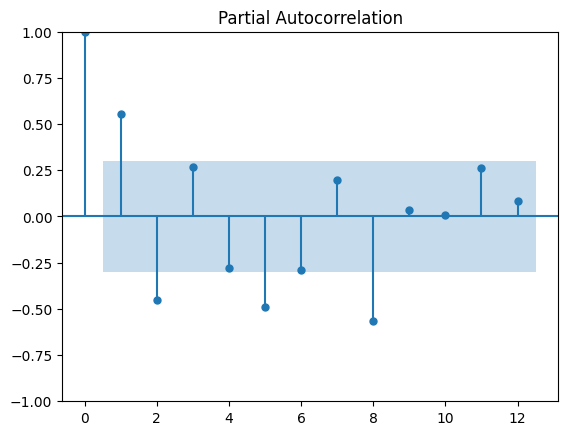

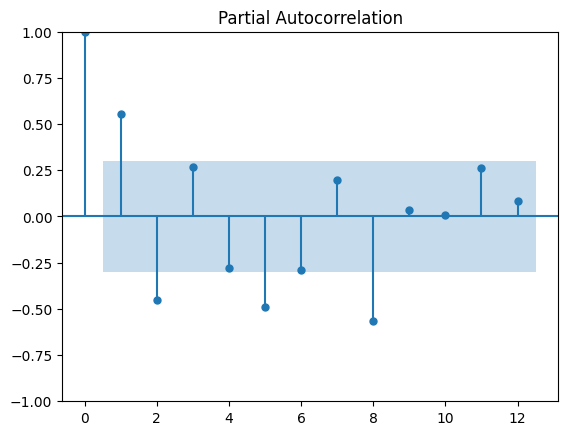

In [52]:
smt.graphics.plot_pacf(ln_ts_diff2, lags=12)

In [22]:
model = sm.tsa.statespace.SARIMAX(ts,
                                      exog = X,
                                      order=(1, 1, 1),
                                      #seasonal_order=(1, 0, 1, 12),
                                      enforce_stationarity=False,
                                      enforce_invertibility=False).fit()

c:\Users\sneha\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\sneha\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [23]:
print(model.summary())

                               SARIMAX Results                                
Dep. Variable:                  Sales   No. Observations:                   44
Model:               SARIMAX(1, 1, 1)   Log Likelihood                -230.820
Date:                Tue, 14 Apr 2026   AIC                            473.639
Time:                        20:43:49   BIC                            483.921
Sample:                    05-01-2011   HQIC                           477.383
                         - 12-01-2014                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
MS             0.3984      0.127      3.128      0.002       0.149       0.648
MS_Lag1        0.2029      0.097      2.099      0.036       0.013       0.392
MS_Lag2       -0.0309      0.122     -0.254      0.8

In [121]:
# SARIMAX because seasonal order is enabled

In [30]:
import sys
import itertools
import warnings

def auto_arima(timeseries, regressors=None, p=range(0, 2), d=range(0, 2), q=range(0, 2),
              P=range(0, 2), D=range(0, 1), Q=range(0, 2)):

    # Generate all different combinations of p, d and q triplets
    pdq = list(itertools.product(p, d, q))

    # Generate all different combinations of seasonal p, q and q triplets
    seasonal_pdq = [(x[0], x[1], x[2], 12) for x in list(itertools.product(P, D, Q))]
    
    warnings.filterwarnings("ignore") # specify to ignore warning messages

    best_aic = np.inf
    best_pdq = None
    best_seasonal_pdq = None
    best_results = None
    
    for param in pdq:
        for param_seasonal in seasonal_pdq:

            try:
                temp_model = sm.tsa.statespace.SARIMAX(endog=timeseries,
                                                 exog=regressors,
                                                 order = param,
                                                 seasonal_order = param_seasonal,
                                                 enforce_stationarity=False,
                                                 enforce_invertibility=False)
                temp_results = temp_model.fit()

                print("SARIMAX{}x{}12 - AIC:{}".format(param, param_seasonal, temp_results.aic))
                
                if temp_results.aic < best_aic:
                    best_aic = temp_results.aic
                    best_pdq = param
                    best_seasonal_pdq = param_seasonal
                    best_results = temp_results
                
            except:
                #print("Unexpected error:", sys.exc_info()[0])
                continue
    print("Best SARIMAX{}x{}12 model - AIC:{}".format(best_pdq, best_seasonal_pdq, best_aic))
    print(best_results.summary().tables[0])
    print(best_results.summary().tables[1])

In [31]:
list(range(0, 2))

[0, 1]

In [ ]:
best_results = auto_arima(ts, X, p=range(0, 2), d=range(0, 2), q=range(0, 2),
                         P=range(0, 2), D=range(0, 2), Q=range(0,2))

SARIMAX(0, 0, 0)x(0, 0, 0, 12)12 - AIC:510.82257050188906
SARIMAX(0, 0, 0)x(0, 0, 1, 12)12 - AIC:1204.9730391523844
SARIMAX(0, 0, 0)x(0, 1, 0, 12)12 - AIC:335.19134808653166
SARIMAX(0, 0, 0)x(0, 1, 1, 12)12 - AIC:211.1245754853564
SARIMAX(0, 0, 0)x(1, 0, 0, 12)12 - AIC:310.0358757787342
SARIMAX(0, 0, 0)x(1, 0, 1, 12)12 - AIC:1328.4456786973471
SARIMAX(0, 0, 0)x(1, 1, 0, 12)12 - AIC:218.4155250911532
SARIMAX(0, 0, 0)x(1, 1, 1, 12)12 - AIC:204.0496813026753
SARIMAX(0, 0, 1)x(0, 0, 0, 12)12 - AIC:486.81113348451123
SARIMAX(0, 0, 1)x(0, 0, 1, 12)12 - AIC:2083.0584758174664
SARIMAX(0, 0, 1)x(0, 1, 0, 12)12 - AIC:311.23144512495634
SARIMAX(0, 0, 1)x(0, 1, 1, 12)12 - AIC:195.9703820104478
SARIMAX(0, 0, 1)x(1, 0, 0, 12)12 - AIC:306.1385210684472
SARIMAX(0, 0, 1)x(1, 0, 1, 12)12 - AIC:1988.0187410954952
SARIMAX(0, 0, 1)x(1, 1, 0, 12)12 - AIC:214.8780639015428
SARIMAX(0, 0, 1)x(1, 1, 1, 12)12 - AIC:190.6302154195379
SARIMAX(0, 1, 0)x(0, 0, 0, 12)12 - AIC:488.13235101899375
SARIMAX(0, 1, 0)x(0, 0

In [33]:
model = sm.tsa.statespace.SARIMAX(ts,
                                      exog = X,
                                      order=(0, 1, 1),
                                      seasonal_order=(0, 0, 0, 12),
                                      enforce_stationarity=False,
                                      enforce_invertibility=False).fit()

In [34]:
ts

Month
2011-05-01    596
2011-06-01    591
2011-07-01    651
2011-08-01    654
2011-09-01    509
2011-10-01    437
2011-11-01    406
2011-12-01    470
2012-01-01    428
2012-02-01    423
2012-03-01    507
2012-04-01    536
2012-05-01    610
2012-06-01    609
2012-07-01    687
2012-08-01    707
2012-09-01    509
2012-10-01    452
2012-11-01    412
2012-12-01    472
2013-01-01    454
2013-02-01    455
2013-03-01    568
2013-04-01    610
2013-05-01    706
2013-06-01    661
2013-07-01    767
2013-08-01    783
2013-09-01    583
2013-10-01    513
2013-11-01    481
2013-12-01    567
2014-01-01    525
2014-02-01    520
2014-03-01    587
2014-04-01    710
2014-05-01    793
2014-06-01    749
2014-07-01    871
2014-08-01    848
2014-09-01    640
2014-10-01    581
2014-11-01    519
2014-12-01    605
Name: Sales, dtype: int64

In [35]:
model.fittedvalues

Month
2011-05-01    435.306499
2011-06-01    502.774191
2011-07-01    577.083966
2011-08-01    736.109759
2011-09-01    590.709757
2011-10-01    414.450927
2011-11-01    518.566097
2011-12-01    477.396803
2012-01-01    401.729642
2012-02-01    397.216076
2012-03-01    481.946238
2012-04-01    493.173514
2012-05-01    465.958163
2012-06-01    649.196130
2012-07-01    667.211185
2012-08-01    687.021263
2012-09-01    639.672643
2012-10-01    551.166591
2012-11-01    463.986796
2012-12-01    476.296570
2013-01-01    408.214204
2013-02-01    373.908586
2013-03-01    486.549342
2013-04-01    611.777648
2013-05-01    623.020763
2013-06-01    632.248426
2013-07-01    649.892043
2013-08-01    686.772876
2013-09-01    665.905621
2013-10-01    539.180909
2013-11-01    465.014729
2013-12-01    586.896059
2014-01-01    545.821313
2014-02-01    568.436330
2014-03-01    623.018505
2014-04-01    600.580219
2014-05-01    693.076039
2014-06-01    846.408691
2014-07-01    814.031919
2014-08-01    702.4

In [36]:
act = data.Sales['2014-01-01':]
pred = model.fittedvalues['2014-01-01':]

In [37]:
print('Training Error:', np.mean(np.abs(act-pred)/act))

Training Error: 0.08502658136016239


In [38]:
#Forecast for next one year
Future_mkt_spend = {
    '2015-01-01' : [600, 559.75, 527.60],
    '2015-02-01' : [550, 600, 559.75],
    '2015-03-01' : [700, 550, 600],
    '2015-04-01' : [590, 700, 550],
    '2015-05-01' : [480, 590, 700],
    '2015-06-01' : [520, 480, 590],
    '2015-07-01' : [800, 520, 480],
    '2015-08-01' : [675, 800, 520],
    '2015-09-01' : [820, 675, 800],
    '2015-10-01' : [710, 820, 675],
    '2015-11-01' : [550, 710, 820],
    '2015-12-01' : [590, 550, 710]
}

In [39]:
Future_mkt_spend = pd.DataFrame(Future_mkt_spend).T

In [40]:
Future_mkt_spend.columns = ['MS', 'MS_Lag1', 'MS_Lag2']

In [41]:
Future_mkt_spend

,MS,MS_Lag1,MS_Lag2
2015-01-01,600.0,559.75,527.60
2015-02-01,550.0,600.00,559.75
2015-03-01,700.0,550.00,600.00
2015-04-01,590.0,700.00,550.00
2015-05-01,480.0,590.00,700.00
2015-06-01,520.0,480.00,590.00
2015-07-01,800.0,520.00,480.00
2015-08-01,675.0,800.00,520.00
2015-09-01,820.0,675.00,800.00
2015-10-01,710.0,820.00,675.00


<Axes: >

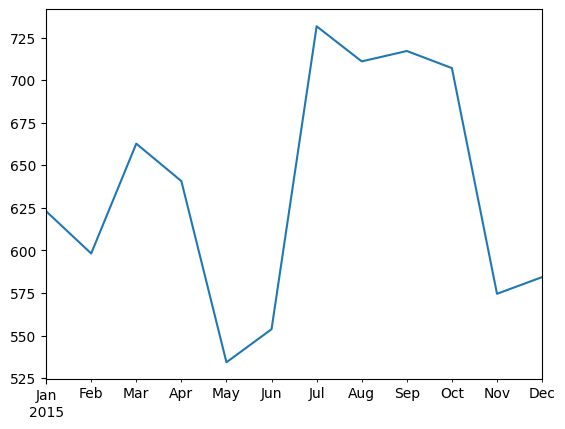

In [42]:
# X varaibles lagged X variables to exog
model.forecast(steps=12, exog = Future_mkt_spend).plot()

In [ ]:
y = Yt-p*et-1*diff*X_lag1*X_lagn

In [148]:
# Expectation: Air Passenger - ETS, ARIMA, SARIMA, 
# No Exogenous variables 
# Make use of UDF functions

In [149]:
# End of the Notebook